In [52]:
import numpy as np
import matplotlib.pyplot as plt

class MusicArenaEnv:
    """Actions discrètes : 0 = tout droit, 1 = gauche 90°, 2 = droite 90°."""
 
    def __init__(self, room_size=15.0, beat_prob=0.10, speed=0.9,
                 window_past=4, window_future=8, wall_horizon=6):
        self.room_size = room_size
        self.beat_prob = beat_prob
        self.speed = speed                    
        self.P = window_past                 
        self.F = window_future                
        self.H = window_future                
        self.max_steps = 200
        self.Hwall = wall_horizon
        self.state_dim = 4 + (self.P + 1 + self.F) + 1 + 1
        self.n_actions = 3
        self.reset()

    def _wall_ahead(self):
        px, py = self.x, self.y
        for j in range(self.Hwall):
            px += self.dir_x * self.speed
            py += self.dir_y * self.speed
            if abs(px) > self.room_size or abs(py) > self.room_size:
                return j
        return self.Hwall
 
    def _beat(self, k):
        return 1.0 if (0 <= k < len(self.beats) and self.beats[k]) else 0.0
 
    def _countdown(self, k):
        for j in range(self.H + 1):
            if self._beat(k + j) >= 0.5:
                return j
        return self.H
 
    def _get_state(self):
        k = self.current_step + 1             
        base = [self.x / self.room_size, self.y / self.room_size,
                self.dir_x, self.dir_y]
        past = [self._beat(k - i) for i in range(self.P, 0, -1)]
        present = [self._beat(k)]
        future = [self._beat(k + i) for i in range(1, self.F + 1)]
        countdown = [self._countdown(k) / self.H]
        wall = [self._wall_ahead() / self.Hwall]
        return np.array(base + past + present + future + countdown + wall, dtype=np.float32)
 
    def reset(self):
        self.x = 0.0
        self.y = 0.0
        self.dir_x = 0.0
        self.dir_y = 1.0                      
        self.current_step = 0
        N = self.max_steps + self.F + 2
        self.beats = np.random.rand(N) < self.beat_prob   
        self.beats[0] = False
        self.history_x = [self.x]
        self.history_y = [self.y]
        self.beat_positions_x = []
        self.beat_positions_y = []
        return self._get_state()
 
    def _apply(self, a):
        if a == 1:                             
            return (-self.dir_y, self.dir_x)
        if a == 2:                             
            return (self.dir_y, -self.dir_x)
        return (self.dir_x, self.dir_y)        
 
    def step(self, a):
        a = int(a)
        self.current_step += 1
        k = self.current_step
        is_beat = self._beat(k) >= 0.5
 
        ux, uy = self._apply(a)
        reward = 0.0

        wall_soon = self._wall_ahead() <= 1
        new_x = self.x + ux * self.speed
        new_y = self.y + uy * self.speed
        stays_in = abs(new_x) <= self.room_size and abs(new_y) <= self.room_size
 
        if is_beat:
            reward += 10.0 if a != 0 else -6.0 
        elif wall_soon:
             reward += 4.0 if (a != 0 and stays_in) else -4.0
        else:
            reward += 2.0 if a == 0 else -2.0    

        if is_beat:
            self.beat_positions_x.append(self.x)
            self.beat_positions_y.append(self.y)
           
        self.x = new_x
        self.y = new_y                    
        hit = False
        if abs(self.x) > self.room_size:
            self.x = float(np.clip(self.x, -self.room_size, self.room_size)); hit = True
        if abs(self.y) > self.room_size:
            self.y = float(np.clip(self.y, -self.room_size, self.room_size)); hit = True
        if hit:
            reward -= 15.0
 
        self.dir_x, self.dir_y = ux, uy
        self.history_x.append(self.x)
        self.history_y.append(self.y)
 
        done = self.current_step >= self.max_steps
        return self._get_state(), float(reward), done
 
    def render(self):
        r = self.room_size
        plt.figure(figsize=(8, 8))
        plt.plot([-r, r, r, -r, -r], [-r, -r, r, r, -r], 'k-', lw=3, label="Murs")
        plt.plot(self.history_x, self.history_y, "b-", alpha=0.7, label="Trajectoire")
        if self.beat_positions_x:
            plt.scatter(self.beat_positions_x, self.beat_positions_y, color='red',
                        marker='*', s=150, zorder=5, label="Beat (virage)")
        plt.plot(self.history_x[0], self.history_y[0], 'go', ms=9, label="Départ")
        plt.plot(self.history_x[-1], self.history_y[-1], 'mo', ms=9, label="Arrivée")
        plt.title("Trajectoire musicale — actions discrètes")
        plt.xlim(-r - 1, r + 1)
        plt.ylim(-r - 1, r + 1)
        plt.legend(loc="upper right")
        plt.grid(True)
        plt.show()


In [53]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
 
 
class PPOAgent(nn.Module):
    """Politique CATEGORIELLE (3 actions). Multimodale par nature :
    sur un beat, gauche ET droite peuvent rester probables toutes les deux."""
 
    def __init__(self, state_dim, n_actions=3):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, n_actions),         
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1),
        )
 
    def act(self, state):
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0)
            dist = Categorical(logits=self.actor(s))
            action = dist.sample()
            logprob = dist.log_prob(action)
            value = self.critic(s)
        return int(action.item()), logprob.item(), value.item()
 
    def evaluate(self, states, actions):
        dist = Categorical(logits=self.actor(states))
        logprobs = dist.log_prob(actions)
        entropy = dist.entropy()
        values = self.critic(states).squeeze(-1)
        return logprobs, values, entropy


In [54]:
class PPOMemory:
    def __init__(self):
        self.clear()
 
    def clear(self):
        self.states, self.actions, self.logprobs = [], [], []
        self.values, self.rewards, self.dones = [], [], []
 


In [55]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95, last_value=0.0):
    vals = values + [last_value]
    advantages, gae = [], 0.0
    for t in reversed(range(len(rewards))):
        mask = 1.0 - float(dones[t])
        delta = rewards[t] + gamma * vals[t + 1] * mask - vals[t]
        gae = delta + gamma * lam * mask * gae
        advantages.insert(0, gae)
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns
 
 
def ppo_update(agent, optimizer, memory, eps_clip=0.2, k_epochs=10,
               c_value=0.5, c_entropy=0.01):
    states = torch.FloatTensor(np.array(memory.states))
    actions = torch.LongTensor(memory.actions)          
    old_logprobs = torch.FloatTensor(memory.logprobs)
 
    advantages, returns = compute_gae(memory.rewards, memory.values, memory.dones)
    advantages = torch.FloatTensor(advantages)
    returns = torch.FloatTensor(returns)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
 
    for _ in range(k_epochs):
        new_logprobs, values, entropy = agent.evaluate(states, actions)
        ratios = torch.exp(new_logprobs - old_logprobs)
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1 - eps_clip, 1 + eps_clip) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()
        critic_loss = nn.MSELoss()(values, returns)
        loss = actor_loss + c_value * critic_loss - c_entropy * entropy.mean()
 
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.parameters(), 0.5)
        optimizer.step()


Début de l'entraînement...
Épisode 100/2000 | score moyen : 18.9
Épisode 200/2000 | score moyen : 323.0
Épisode 300/2000 | score moyen : 409.4
Épisode 400/2000 | score moyen : 443.1
Épisode 500/2000 | score moyen : 471.6
Épisode 600/2000 | score moyen : 497.0
Épisode 700/2000 | score moyen : 496.7
Épisode 800/2000 | score moyen : 514.1
Épisode 900/2000 | score moyen : 514.0
Épisode 1000/2000 | score moyen : 519.9
Épisode 1100/2000 | score moyen : 527.2
Épisode 1200/2000 | score moyen : 532.5
Épisode 1300/2000 | score moyen : 538.1
Épisode 1400/2000 | score moyen : 538.1
Épisode 1500/2000 | score moyen : 541.8
Épisode 1600/2000 | score moyen : 537.5
Épisode 1700/2000 | score moyen : 539.1
Épisode 1800/2000 | score moyen : 547.3
Épisode 1900/2000 | score moyen : 542.6
Épisode 2000/2000 | score moyen : 538.6
Éval : beats tournés 30/30 (100%) | virages hors-beat 5 (normalement ~évitements de murs) | contacts murs 0


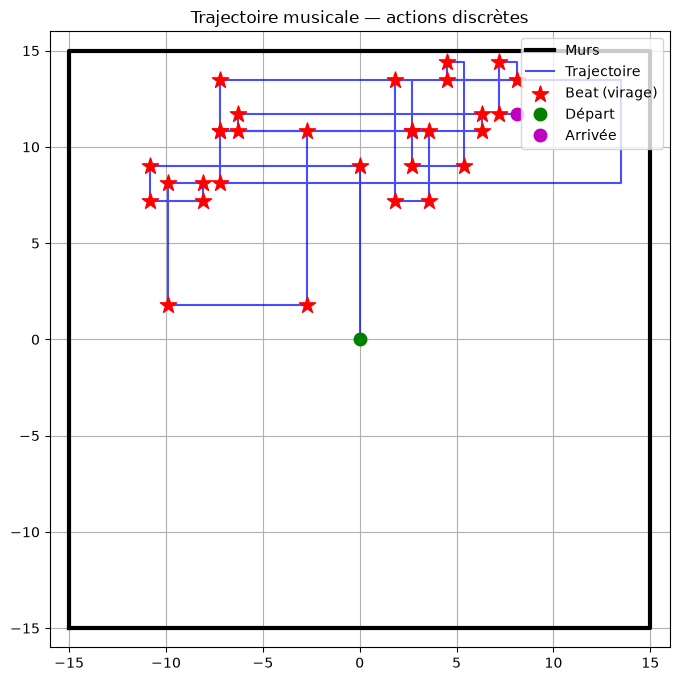

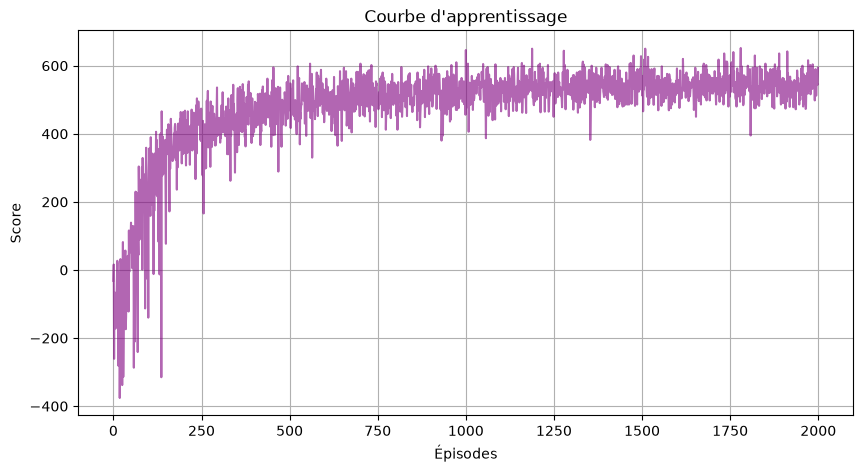

In [56]:
import torch.optim as optim
 
env = MusicArenaEnv()
agent = PPOAgent(state_dim=env.state_dim, n_actions=env.n_actions)
optimizer = optim.Adam(agent.parameters(), lr=3e-4)
memory = PPOMemory()
 
max_episodes = 2000
update_timestep = 2000
timestep_counter = 0
historique_scores = []
 
print("Début de l'entraînement...")
for episode in range(1, max_episodes + 1):
    state = env.reset()
    sc, done = 0.0, False
    while not done:
        timestep_counter += 1
        action, logprob, value = agent.act(state)
        next_state, reward, done = env.step(action)
        memory.states.append(state)
        memory.actions.append(action)
        memory.logprobs.append(logprob)
        memory.values.append(value)
        memory.rewards.append(reward)
        memory.dones.append(done)
        state = next_state
        sc += reward
        if timestep_counter % update_timestep == 0:
            ppo_update(agent, optimizer, memory)
            memory.clear()
    historique_scores.append(sc)
    if episode % 100 == 0:
        print(f"Épisode {episode}/{max_episodes} | score moyen : "
              f"{np.mean(historique_scores[-100:]):.1f}")



state = env.reset()
done = False
beats_ok = beats_tot = virages_hors_beat = murs = 0
while not done:
    k = env.current_step + 1
    is_b = env._beat(k) >= 0.5
    with torch.no_grad():
        a = int(torch.argmax(agent.actor(torch.FloatTensor(state).unsqueeze(0))).item())
    state, _, done = env.step(a)
    if is_b:
        beats_tot += 1
        if a != 0:
            beats_ok += 1
    elif a != 0:
        virages_hors_beat += 1
    if abs(env.x) >= env.room_size or abs(env.y) >= env.room_size:
        murs += 1
print(f"Éval : beats tournés {beats_ok}/{beats_tot} "
      f"({100*beats_ok/max(beats_tot,1):.0f}%) | virages hors-beat {virages_hors_beat} "
      f"(normalement ~évitements de murs) | contacts murs {murs}")
env.render()
 
plt.figure(figsize=(10, 5))
plt.plot(historique_scores, color="purple", alpha=0.6)
plt.title("Courbe d'apprentissage")
plt.xlabel("Épisodes")
plt.ylabel("Score")
plt.grid(True)
plt.show()
